# Buổi 4 · Ngân hàng tình huống Perceptron

Notebook gồm **10 chủ đề mở** và một mẫu thực hành từng bước. Không có dữ liệu hoặc lời giải dựng sẵn; các code cell chỉ chứa comment định hướng để mỗi nhóm tự thu thập dữ liệu, xử lý, huấn luyện, triển khai thử và kiểm thử.

## Khung suy nghĩ chung

Trước khi viết code, hãy trả lời bằng lời:

1. Đối tượng cần phân loại là gì?
2. Hai nhãn `0` và `1` có ý nghĩa gì?
3. Feature nào có thể biết **trước thời điểm ra quyết định**?
4. Feature nào có thể vô tình chứa đáp án và gây data leakage?
5. Sai lớp nào gây hậu quả lớn hơn?
6. Vì sao một ranh giới tuyến tính có thể phù hợp hoặc chưa phù hợp?

## 01 · Cảnh báo máy quá tải

Dùng nhiệt độ động cơ, độ rung, dòng điện và thời gian chạy để dự đoán máy có cần dừng kiểm tra hay không. Hãy tập trung phân tích lỗi **bỏ sót một máy nguy hiểm**.

In [ ]:
# Nếu chọn tình huống 01, hãy tự thiết kế dữ liệu và viết code tại đây.

## 02 · Quyết định tưới cây

Dùng độ ẩm đất, nhiệt độ, thời gian từ lần tưới gần nhất và dự báo mưa để quyết định bật máy bơm. Hãy kiểm tra dấu của từng trọng số có khớp với trực giác hay không.

In [ ]:
# Nếu chọn tình huống 02, hãy tự thiết kế dữ liệu và viết code tại đây.

## 03 · Cảnh báo giao hàng trễ

Dùng khoảng cách, số đơn tài xế đang giữ, trời mưa, giờ cao điểm và thời gian chuẩn bị để dự đoán nguy cơ giao trễ. Hãy tự quyết định cách mã hoá các feature có/không.

In [ ]:
# Nếu chọn tình huống 03, hãy tự thiết kế dữ liệu và viết code tại đây.

## 04 · Kiểm tra sản phẩm cuối dây chuyền

Dùng độ lệch khối lượng, độ lệch kích thước, số vết xước và điểm màu để dự đoán sản phẩm có cần kiểm tra lại hay không. Hãy suy nghĩ vì sao **độ lệch tuyệt đối** hữu ích hơn kích thước thô.

In [ ]:
# Nếu chọn tình huống 04, hãy tự thiết kế dữ liệu và viết code tại đây.

## 05 · Ưu tiên phiếu hỗ trợ khách hàng

Dùng số từ khẩn cấp, trạng thái gián đoạn dịch vụ, thời gian chờ và mức khách hàng để dự đoán phiếu có cần ưu tiên. Hãy nêu feature nào có nguy cơ gây thiên lệch và quyết định nào vẫn cần con người xem lại.

In [ ]:
# Nếu chọn tình huống 05, hãy tự thiết kế dữ liệu và viết code tại đây.

## 06 · Đề xuất miễn phí vận chuyển

Dùng giá trị đơn hàng, khoảng cách, hạng thành viên và khối lượng kiện hàng để đề xuất miễn phí vận chuyển. Hãy tạo thêm các mẫu nằm gần ranh giới thay vì chỉ tạo những trường hợp quá dễ.

In [1]:
# Nếu chọn tình huống 06, hãy tự thiết kế dữ liệu và viết code tại đây.
import numpy as np

X = np.array([
    [150, 10, 0, 5],
    [200, 8, 1, 4],
    [250, 12, 0, 6],
    [300, 10, 1, 5],
    [350, 8, 1, 4],
    [400, 7, 1, 3],
    [450, 6, 2, 4],
    [500, 5, 2, 3],
    [600, 8, 1, 4],
    [700, 10, 2, 5],

    # Các mẫu gần ranh giới
    [300, 8, 1, 3],
    [350, 7, 1, 4],
    [400, 9, 1, 4],
    [450, 8, 2, 5],
    [500, 9, 1, 5]
])

y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1,
    0, 1, 0, 1, 1
])


# Chuẩn hóa dữ liệu
mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X - mean) / std


class Perceptron:

    def __init__(self, learning_rate=0.1, max_epochs=100):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs

        self.weights = np.zeros(4)
        self.bias = 0

    def predict_one(self, x):
        net = np.dot(x, self.weights) + self.bias

        if net >= 0:
            return 1
        else:
            return 0

    def fit(self, X, y):

        for epoch in range(self.max_epochs):

            errors = 0

            for x, target in zip(X, y):

                prediction = self.predict_one(x)

                error = target - prediction

                if error != 0:

                    self.weights += (
                        self.learning_rate * error * x
                    )

                    self.bias += (
                        self.learning_rate * error
                    )

                    errors += 1

            print(
                "Epoch:", epoch + 1,
                "| Errors:", errors
            )

            if errors == 0:
                break


# Huấn luyện mô hình
model = Perceptron(
    learning_rate=0.1,
    max_epochs=100
)

model.fit(X_scaled, y)


# In trọng số
print("\nTrọng số:")

print("w1 =", model.weights[0])
print("w2 =", model.weights[1])
print("w3 =", model.weights[2])
print("w4 =", model.weights[3])

print("bias =", model.bias)


# Dự đoán dữ liệu
predictions = []

for x in X_scaled:
    predictions.append(
        model.predict_one(x)
    )


print("\nNhãn thật:")
print(y)

print("\nNhãn dự đoán:")
print(predictions)


# Tính Accuracy
correct = 0

for actual, predicted in zip(y, predictions):

    if actual == predicted:
        correct += 1

accuracy = correct / len(y)

print("\nAccuracy =", accuracy * 100, "%")


# Dự đoán một đơn hàng mới
new_order = np.array([400, 8, 1, 4])

new_order_scaled = (
    new_order - mean
) / std


# Tính Net
net = (
    np.dot(new_order_scaled, model.weights)
    + model.bias
)

prediction = model.predict_one(
    new_order_scaled
)


print("\nĐơn hàng mới:")

print(
    "Giá trị:",
    new_order[0],
    "nghìn đồng"
)

print(
    "Khoảng cách:",
    new_order[1],
    "km"
)

print(
    "Hạng thành viên: Silver"
)

print(
    "Khối lượng:",
    new_order[3],
    "kg"
)

print("\nNet =", net)


if prediction == 1:

    print(
        "Kết quả: ĐỀ XUẤT MIỄN PHÍ VẬN CHUYỂN"
    )

else:

    print(
        "Kết quả: KHÁCH TRẢ PHÍ VẬN CHUYỂN"
    )


# Thử các Learning Rate khác nhau
learning_rates = [0.01, 0.1, 0.5, 1.0]

print("\nSo sánh Learning Rate:")

for lr in learning_rates:

    test_model = Perceptron(
        learning_rate=lr,
        max_epochs=100
    )

    test_model.fit(X_scaled, y)

    predictions = []

    for x in X_scaled:
        predictions.append(
            test_model.predict_one(x)
        )

    correct = 0

    for actual, predicted in zip(
        y,
        predictions
    ):

        if actual == predicted:
            correct += 1

    accuracy = correct / len(y)

    print(
        "Learning rate:",
        lr,
        "| Accuracy:",
        accuracy * 100,
        "%"
    )

Epoch: 1 | Errors: 3
Epoch: 2 | Errors: 3
Epoch: 3 | Errors: 0

Trọng số:
w1 = 0.21061636974040907
w2 = -0.2353393621658208
w3 = 0.16174915980515758
w4 = 0.0
bias = 0.0

Nhãn thật:
[0 0 0 0 0 1 1 1 1 1 0 1 0 1 1]

Nhãn dự đoán:
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1]

Accuracy = 100.0 %

Đơn hàng mới:
Giá trị: 400 nghìn đồng
Khoảng cách: 8 km
Hạng thành viên: Silver
Khối lượng: 4 kg

Net = 0.02112773749086453
Kết quả: ĐỀ XUẤT MIỄN PHÍ VẬN CHUYỂN

So sánh Learning Rate:
Epoch: 1 | Errors: 3
Epoch: 2 | Errors: 3
Epoch: 3 | Errors: 0
Learning rate: 0.01 | Accuracy: 100.0 %
Epoch: 1 | Errors: 3
Epoch: 2 | Errors: 3
Epoch: 3 | Errors: 0
Learning rate: 0.1 | Accuracy: 100.0 %
Epoch: 1 | Errors: 3
Epoch: 2 | Errors: 3
Epoch: 3 | Errors: 0
Learning rate: 0.5 | Accuracy: 100.0 %
Epoch: 1 | Errors: 3
Epoch: 2 | Errors: 3
Epoch: 3 | Errors: 0
Learning rate: 1.0 | Accuracy: 100.0 %


## 07 · Cảnh báo thông gió phòng học

Dùng nồng độ CO2, nhiệt độ, độ ẩm, số người và thời gian đóng cửa để dự đoán khi nào cần thông gió. Hãy tự đề xuất cách gắn nhãn mà không biến một ngưỡng CO2 duy nhất thành đáp án có sẵn.

In [ ]:
# Nếu chọn tình huống 07, hãy tự thiết kế dữ liệu và viết code tại đây.

## 08 · Lọc email rác đơn giản

Chuyển email thành các feature số như số liên kết, số từ viết hoa, số dấu chấm than và độ dài tiêu đề. Hãy ẩn thông tin cá nhân, ghi lại quy tắc gắn nhãn và so sánh hậu quả của chặn nhầm với bỏ sót thư rác.

In [ ]:
# Nếu chọn tình huống 08, hãy tự thiết kế dữ liệu và viết code tại đây.

## 09 · Cảnh báo nhập thêm hàng

Dùng tồn kho, lượng bán trung bình, thời gian chờ hàng và số đơn đang chờ để dự đoán có cần nhập thêm hay không. Hãy ghi rõ mốc thời gian quan sát để dữ liệu tương lai không lọt vào feature.

In [ ]:
# Nếu chọn tình huống 09, hãy tự thiết kế dữ liệu và viết code tại đây.

## 10 · Gợi ý hỗ trợ học tập

Dùng dữ liệu học tập phù hợp như tỷ lệ tham dự, mức hoàn thành bài luyện tập, số bài nộp trễ và điểm quiz gần nhất để gợi ý hỗ trợ thêm. Đây chỉ là tín hiệu để giảng viên xem xét, không phải kết luận về năng lực sinh viên.

In [ ]:
# Nếu chọn tình huống 10, hãy tự thiết kế dữ liệu và viết code tại đây.

## Phiếu thiết kế trước khi lập trình

| Mục | Câu trả lời của nhóm |
| --- | --- |
| Tình huống đã chọn |đề xuất miễn phí vận chuyển   |
| Đối tượng được phân loại |các đơn của khách hàng   |
| Ý nghĩa nhãn 0 / 1 | 0:khách hàng trả phí vận chuyển 1: Đề xuất miễn phí vận chuyển. |
| Danh sách feature và đơn vị | Giá trị đơn hàng (nghìn đồng), khoảng cách giao hàng (km), hạng thành viên (Bronze = 0, Silver = 1, Gold = 2), khối lượng kiện hàng (kg). |
| Cách tạo / thu thập dữ liệu | Tự xây dựng một tập dữ liệu mẫu dựa trên các tình huống đơn hàng thực tế. Tạo cả các trường hợp dễ phân loại và các trường hợp gần ranh giới giữa 0 và 1. |
| Lỗi cần ưu tiên giảm |Ưu tiên giảm trường hợp đề xuất miễn phí vận chuyển cho đơn hàng không phù hợp, vì cửa hàng có thể phải chịu thêm chi phí vận chuyển.  |
| Dự đoán giới hạn của Perceptron | Perceptron chỉ phù hợp với dữ liệu có thể phân chia tương đối rõ bằng một ranh giới tuyến tính. Với các đơn hàng phức tạp, kết quả có thể chưa chính xác. |
| Người chịu trách nhiệm xem lại dự đoán |Nhân viên quản lý đơn hàng hoặc người phụ trách chính sách vận chuyển.  |

# Mẫu thực hành step by step

Đi lần lượt từ Bước 0 đến Bước 10. Mỗi bước có **việc cần làm**, **kết quả cần ghi lại** và một code cell chỉ chứa comment. Không xoá phần giải thích; hãy viết code của nhóm ngay dưới comment tương ứng.

## Bước 0 · Đóng khung bài toán

- Chọn đúng **một** trong 10 tình huống.
- Viết câu hỏi mà mô hình phải trả lời tại một thời điểm cụ thể.
- Định nghĩa rõ `y = 0`, `y = 1` và hành động sau mỗi dự đoán.
- Chọn lỗi cần ưu tiên giảm: false positive hay false negative.

**Kết quả cần ghi:** một đoạn 3–5 câu, không bắt đầu bằng code.

In [ ]:

TARGET_NAME = "free_shipping"

LABEL_MAP = {
    0: "Voucher / Không miễn phí vận chuyển",
    1: "Đề xuất miễn phí vận chuyển"
}

IMPORTANT_ERROR = "False Positive"

print("Tình huống: Tình huống 06 - Đề xuất miễn phí vận chuyển")
print("y = 0:", LABEL_MAP[0])
print("y = 1:", LABEL_MAP[1])
print("Ưu tiên giảm:", IMPORTANT_ERROR)

## Bước 1 · Lập kế hoạch thu thập và gắn nhãn

1. Chọn **đơn vị quan sát**: mỗi dòng dữ liệu đại diện cho điều gì?
2. Lập data dictionary gồm tên cột, ý nghĩa, đơn vị, kiểu dữ liệu và phạm vi hợp lý.
3. Chọn nguồn: đo thực tế, ghi nhận thủ công, dữ liệu công khai hoặc mô phỏng. Nếu mô phỏng, phải công bố quy tắc tạo.
4. Mô tả ai gắn nhãn, gắn ở thời điểm nào và xử lý bất đồng ra sao.
5. Không thu thập dữ liệu cá nhân không cần thiết; ẩn danh trước khi đưa vào notebook.
6. Cố gắng có đủ cả hai lớp và các trường hợp gần ranh giới, không chỉ các mẫu dễ.

**Kết quả cần ghi:** data dictionary, nguồn dữ liệu, số mẫu dự kiến và quy tắc gắn nhãn.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

CSV_PATH = "../data/ecommerce_sales_34500.csv"

df = pd.read_csv(CSV_PATH)

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df = df.sort_values(
    by=["customer_id", "order_date"]
).reset_index(drop=True)

df["previous_spending"] = (
    df.groupby("customer_id")["total_amount"].cumsum()
    - df["total_amount"]
)

df["previous_orders"] = (
    df.groupby("customer_id").cumcount()
)

def get_membership(row):
    if row["previous_spending"] >= 1500 or row["previous_orders"] >= 8:
        return "VIP"
    elif row["previous_spending"] >= 800 or row["previous_orders"] >= 5:
        return "Gold"
    elif row["previous_spending"] >= 300 or row["previous_orders"] >= 2:
        return "Silver"
    else:
        return "Bronze"

df["membership_level"] = df.apply(
    get_membership,
    axis=1
)

membership_map = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "VIP": 3
}

df["membership_code"] = df[
    "membership_level"
].map(membership_map)

np.random.seed(42)

df["distance_km"] = np.random.uniform(
    1,
    30,
    len(df)
)

def create_label(row):
    high_value = row["total_amount"] >= 100
    loyal_customer = row["membership_level"] in ["Gold", "VIP"]
    short_distance = row["distance_km"] <= 10
    reasonable_order = row["total_amount"] >= 70

    if high_value and short_distance:
        return 1

    elif loyal_customer and short_distance and reasonable_order:
        return 1

    else:
        return 0

df["y"] = df.apply(
    create_label,
    axis=1
)

print(df.shape)
display(df.head())

print(df["y"].value_counts())

(34500, 23)


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,shipping_cost,profit_margin,customer_age,customer_gender,previous_spending,previous_orders,membership_level,membership_code,distance_km,y
0,O124096,C10000,P204633,Fashion,38.97,0.15,1,Debit Card,2024-08-17,4,...,6.04,5.55,54,Male,0.00,0,Bronze,0,11.861663,0
1,O129389,C10000,P219146,Electronics,177.46,0.00,1,Debit Card,2025-09-07,4,...,7.14,14.16,37,Male,33.12,1,Bronze,0,28.570715,0
2,O109434,C10001,P229184,Home,225.62,0.00,3,Debit Card,2024-01-20,6,...,8.43,181.09,62,Male,0.00,0,Bronze,0,22.227824,0
3,O102672,C10001,P218001,Sports,102.88,0.00,2,Credit Card,2024-03-24,6,...,8.47,53.26,40,Female,676.86,1,Silver,1,18.361096,0
4,O128260,C10001,P215507,Electronics,187.56,0.00,3,Credit Card,2024-08-19,4,...,9.55,57.97,40,Male,882.62,2,Gold,2,5.524541,1


y
0    30413
1     4087
Name: count, dtype: int64


## Bước 2 · Đọc và kiểm tra dữ liệu thô

- Đọc CSV và hiển thị một số dòng đầu/cuối.
- Kiểm tra kích thước bảng, kiểu dữ liệu, giá trị thiếu, dòng trùng và giá trị ngoài phạm vi.
- Đếm số mẫu của từng nhãn; không kết luận chỉ từ accuracy nếu lớp bị lệch.
- Giữ một bản dữ liệu thô bất biến để có thể đối chiếu.

**Kết quả cần ghi:** bảng tóm tắt vấn đề dữ liệu và quyết định xử lý cho từng vấn đề.

HEAD


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,shipping_cost,profit_margin,customer_age,customer_gender,previous_spending,previous_orders,membership_level,membership_code,distance_km,y
0,O124096,C10000,P204633,Fashion,38.97,0.15,1,Debit Card,2024-08-17,4,...,6.04,5.55,54,Male,0.00,0,Bronze,0,11.861663,0
1,O129389,C10000,P219146,Electronics,177.46,0.00,1,Debit Card,2025-09-07,4,...,7.14,14.16,37,Male,33.12,1,Bronze,0,28.570715,0
2,O109434,C10001,P229184,Home,225.62,0.00,3,Debit Card,2024-01-20,6,...,8.43,181.09,62,Male,0.00,0,Bronze,0,22.227824,0
3,O102672,C10001,P218001,Sports,102.88,0.00,2,Credit Card,2024-03-24,6,...,8.47,53.26,40,Female,676.86,1,Silver,1,18.361096,0
4,O128260,C10001,P215507,Electronics,187.56,0.00,3,Credit Card,2024-08-19,4,...,9.55,57.97,40,Male,882.62,2,Gold,2,5.524541,1


TAIL


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,shipping_cost,profit_margin,customer_age,customer_gender,previous_spending,previous_orders,membership_level,membership_code,distance_km,y
34495,O121574,C17998,P200252,Home,164.04,0.00,1,Debit Card,2025-08-10,7,...,5.93,40.00,51,Male,138.44,3,Silver,1,29.401664,0
34496,O117730,C17999,P241142,Electronics,858.93,0.05,1,PayPal,2024-05-28,6,...,10.41,87.51,35,Male,0.00,0,Bronze,0,13.358775,0
34497,O132004,C17999,P206224,Home,112.09,0.00,1,UPI,2024-06-23,3,...,9.30,22.09,20,Male,815.98,1,Gold,2,23.880868,0
34498,O103873,C17999,P216827,Home,259.07,0.00,2,Debit Card,2024-09-04,4,...,9.56,135.52,57,Other,928.07,2,Gold,2,20.017951,0
34499,O113715,C17999,P238419,Electronics,685.66,0.00,1,COD,2025-07-08,5,...,9.06,73.22,65,Male,1446.21,3,Gold,2,4.390589,1


SHAPE
(34500, 23)
DTYPES
order_id                         str
customer_id                      str
product_id                       str
category                         str
price                        float64
discount                     float64
quantity                       int64
payment_method                   str
order_date            datetime64[us]
delivery_time_days             int64
region                           str
returned                         str
total_amount                 float64
shipping_cost                float64
profit_margin                float64
customer_age                   int64
customer_gender                  str
previous_spending            float64
previous_orders                int64
membership_level                 str
membership_code                int64
distance_km                  float64
y                              int64
dtype: object
MISSING
order_id              0
customer_id           0
product_id            0
category              0
price 

,count,mean,std,min,25%,50%,75%,max
price,34500.0,119.391632,195.620477,1.010000,16.690000,45.660000,130.950000,2930.47000
discount,34500.0,0.049291,0.069894,0.000000,0.000000,0.000000,0.100000,0.30000
quantity,34500.0,1.490725,0.932270,1.000000,1.000000,1.000000,2.000000,5.00000
delivery_time_days,34500.0,4.814203,1.242141,3.000000,4.000000,5.000000,6.000000,13.00000
total_amount,34500.0,170.008494,357.503014,0.820000,19.710000,56.820000,168.530000,12931.80000
shipping_cost,34500.0,6.152120,2.389539,0.000000,4.420000,6.090000,7.830000,15.65000
profit_margin,34500.0,28.116505,53.352947,-6.200000,1.500000,10.550000,33.132500,1536.17000
customer_age,34500.0,43.474377,14.980682,18.000000,31.000000,43.000000,56.000000,69.00000
distance_km,34500.0,15.485387,8.353773,1.000161,8.260715,15.508464,22.687285,29.99782
previous_spending,34500.0,375.581445,665.358429,0.000000,7.567500,137.535000,462.812500,13861.78000


RANGE
price -> 1.01 2930.47
discount -> 0.0 0.3
quantity -> 1 5
delivery_time_days -> 3 13
total_amount -> 0.82 12931.8
shipping_cost -> 0.0 15.65
profit_margin -> -6.2 1536.17
customer_age -> 18 69
distance_km -> 1.0001605635964017 29.99781997816212
previous_spending -> 0.0 13861.779999999999
previous_orders -> 0 12
membership_code -> 0 3
LABEL DISTRIBUTION


y
0    30413
1     4087
Name: count, dtype: int64

LABEL PERCENTAGE


y
0    88.15
1    11.85
Name: proportion, dtype: float64

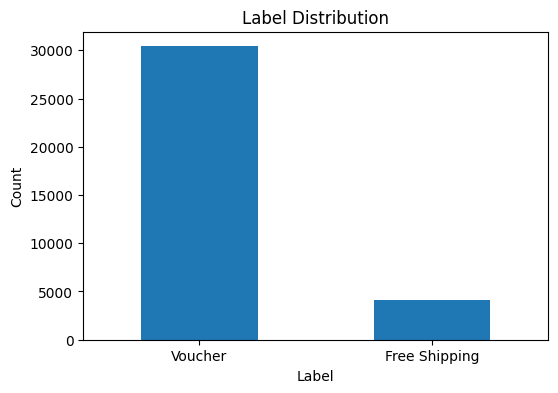

In [4]:
# STEP 2

print("HEAD")
display(df.head())

print("TAIL")
display(df.tail())

print("SHAPE")
print(df.shape)

print("DTYPES")
print(df.dtypes)

print("MISSING")
print(df.isnull().sum())

print("DUPLICATES")
print(df.duplicated().sum())

numeric_columns = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age",
    "distance_km",
    "previous_spending",
    "previous_orders",
    "membership_code"
]

print("DESCRIBE")
display(
    df[numeric_columns].describe().T
)

print("RANGE")

for column in numeric_columns:
    print(
        column,
        "->",
        df[column].min(),
        df[column].max()
    )

print("LABEL DISTRIBUTION")

label_distribution = (
    df["y"]
    .value_counts()
    .sort_index()
)

display(label_distribution)

print("LABEL PERCENTAGE")

display(
    df["y"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

plt.figure(figsize=(6, 4))

df["y"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(
    [0, 1],
    ["Voucher", "Free Shipping"],
    rotation=0
)

plt.show()

## Bước 3 · Chọn feature và kiểm tra data leakage

Với từng cột, hỏi: **giá trị này có thật sự tồn tại trước lúc mô hình ra quyết định không?** Loại cột định danh, cột chứa trực tiếp đáp án và thông tin chỉ xuất hiện sau kết quả. Sau đó xác định thứ tự cố định cho các feature trong `X` và nhãn trong `y`.

**Kết quả cần ghi:** danh sách feature được giữ/loại cùng lý do.

In [5]:
# STEP 3

feature_names = [
    "total_amount",
    "distance_km",
    "membership_code"
]

target_name = "y"

X = df[feature_names].copy()

y = df[target_name].copy()

assert len(X) == len(y)

assert set(y.unique()).issubset({0, 1})

assert list(X.columns) == feature_names

print("Features:")
print(feature_names)

print("Target:")
print(target_name)

print("X shape:")
print(X.shape)

print("y shape:")
print(y.shape)

print("Unique labels:")
print(sorted(y.unique()))

removed_features = [
    "order_id",
    "customer_id",
    "product_id",
    "shipping_cost",
    "delivery_time_days",
    "returned",
    "profit_margin",
    "y"
]

print("Removed features:")
print(removed_features)

Features:
['total_amount', 'distance_km', 'membership_code']
Target:
y
X shape:
(34500, 3)
y shape:
(34500,)
Unique labels:
[np.int64(0), np.int64(1)]
Removed features:
['order_id', 'customer_id', 'product_id', 'shipping_cost', 'delivery_time_days', 'returned', 'profit_margin', 'y']


## Bước 4 · Chia train/test trước khi học tham số xử lý

- Chọn cách chia ngẫu nhiên có giữ tỷ lệ lớp hoặc chia theo thời gian, tuỳ tình huống.
- Đặt `random_state` để tái lập kết quả nếu chia ngẫu nhiên.
- Tuyệt đối không dùng test để chọn feature, tính trung bình/độ lệch chuẩn hay điều chỉnh mô hình.

**Kết quả cần ghi:** kích thước và phân bố nhãn của train/test; giải thích cách chia.

In [6]:
# STEP 4

df = df.sort_values(
    by="order_date"
).reset_index(drop=True)

X = df[feature_names].copy()

y = df["y"].copy()

split_index = int(
    len(df) * 0.8
)

X_train = X.iloc[
    :split_index
].copy()

X_test = X.iloc[
    split_index:
].copy()

y_train = y.iloc[
    :split_index
].copy()

y_test = y.iloc[
    split_index:
].copy()

print("Total:", len(df))
print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("Train labels:")
print(
    y_train.value_counts()
    .sort_index()
)

print("Train percentage:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Test labels:")
print(
    y_test.value_counts()
    .sort_index()
)

print("Test percentage:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Total: 34500
Train: (27600, 3)
Test : (6900, 3)
Train labels:
y
0    24381
1     3219
Name: count, dtype: int64
Train percentage:
y
0    88.34
1    11.66
Name: proportion, dtype: float64
Test labels:
y
0    6032
1     868
Name: count, dtype: int64
Test percentage:
y
0    87.42
1    12.58
Name: proportion, dtype: float64


## Bước 5 · Làm sạch và biến đổi dữ liệu

- Quyết định cách xử lý missing, duplicate và outlier; không âm thầm xoá dữ liệu.
- Mã hoá feature phân loại thành số nếu có.
- Chuẩn hoá feature có thang đo khác nhau. Chỉ `fit` bộ biến đổi trên train, sau đó dùng cùng tham số để `transform` test.
- Kiểm tra sau xử lý không còn `NaN`, vô cùng hoặc sai thứ tự cột.

**Kết quả cần ghi:** quy tắc xử lý và tham số cần tái sử dụng khi triển khai.

In [7]:
# STEP 5

print("Missing values:")

print(
    X_train.isnull().sum()
)

print(
    X_test.isnull().sum()
)

train_medians = X_train.median()

X_train = X_train.fillna(
    train_medians
)

X_test = X_test.fillna(
    train_medians
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Train shape:")
print(X_train_scaled.shape)

print("Test shape:")
print(X_test_scaled.shape)

print("Train mean:")
print(
    X_train_scaled.mean(axis=0)
)

print("Train std:")
print(
    X_train_scaled.std(axis=0)
)

print("Train NaN:")
print(
    np.isnan(X_train_scaled).any()
)

print("Train Inf:")
print(
    np.isinf(X_train_scaled).any()
)

print("Test NaN:")
print(
    np.isnan(X_test_scaled).any()
)

print("Test Inf:")
print(
    np.isinf(X_test_scaled).any()
)

assert not np.isnan(X_train_scaled).any()
assert not np.isnan(X_test_scaled).any()
assert not np.isinf(X_train_scaled).any()
assert not np.isinf(X_test_scaled).any()

Missing values:
total_amount       0
distance_km        0
membership_code    0
dtype: int64
total_amount       0
distance_km        0
membership_code    0
dtype: int64
Train shape:
(27600, 3)
Test shape:
(6900, 3)
Train mean:
[ 1.80210114e-17 -2.02478935e-16 -6.59054132e-17]
Train std:
[1. 1. 1.]
Train NaN:
False
Train Inf:
False
Test NaN:
False
Test Inf:
False


## Bước 6 · Huấn luyện Perceptron

- Chọn learning rate, số epoch và giá trị khởi tạo `w`, `b`.
- Với mỗi mẫu, tính `net = wᵀx + b`, đưa qua hàm step để có `ŷ`, rồi tính `e = y - ŷ`.
- Chỉ cập nhật khi dự đoán sai; lưu số lỗi theo epoch để quan sát hội tụ.
- Có thể dùng lớp tự cài đặt hoặc thư viện, nhưng phải giải thích được `w`, `b` và một lượt cập nhật.

**Kết quả cần ghi:** cấu hình, số epoch thực tế, trọng số/bias cuối và đồ thị số lỗi.

Epoch 1: errors = 3762
Epoch 2: errors = 3725
Epoch 3: errors = 3731
Epoch 4: errors = 3787
Epoch 5: errors = 3767
Epoch 6: errors = 3720
Epoch 7: errors = 3693
Epoch 8: errors = 3739
Epoch 9: errors = 3730
Epoch 10: errors = 3727
Epoch 11: errors = 3722
Epoch 12: errors = 3752
Epoch 13: errors = 3719
Epoch 14: errors = 3715
Epoch 15: errors = 3749
Epoch 16: errors = 3744
Epoch 17: errors = 3730
Epoch 18: errors = 3727
Epoch 19: errors = 3685
Epoch 20: errors = 3724
Epoch 21: errors = 3724
Epoch 22: errors = 3738
Epoch 23: errors = 3721
Epoch 24: errors = 3719
Epoch 25: errors = 3696
Epoch 26: errors = 3763
Epoch 27: errors = 3731
Epoch 28: errors = 3729
Epoch 29: errors = 3750
Epoch 30: errors = 3733
Epoch 31: errors = 3743
Epoch 32: errors = 3708
Epoch 33: errors = 3749
Epoch 34: errors = 3695
Epoch 35: errors = 3702
Epoch 36: errors = 3723
Epoch 37: errors = 3748
Epoch 38: errors = 3724
Epoch 39: errors = 3717
Epoch 40: errors = 3728
Epoch 41: errors = 3711
Epoch 42: errors = 3715
E

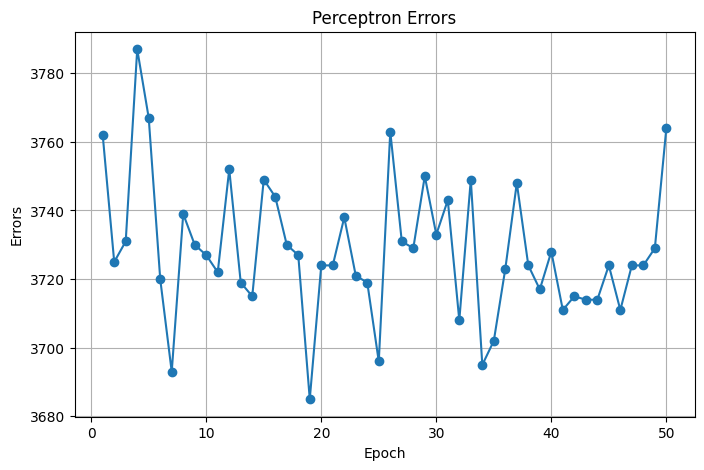

In [8]:
# STEP 6

X_train_np = X_train_scaled
y_train_np = y_train.to_numpy()

learning_rate = 0.01
epochs = 50

w = np.zeros(
    X_train_np.shape[1]
)

b = 0.0

errors_history = []

for epoch in range(epochs):

    errors = 0

    for i in range(len(X_train_np)):

        x_i = X_train_np[i]
        y_i = y_train_np[i]

        net = np.dot(
            w,
            x_i
        ) + b

        if net >= 0:
            y_hat = 1
        else:
            y_hat = 0

        error = y_i - y_hat

        if error != 0:

            w = (
                w
                + learning_rate
                * error
                * x_i
            )

            b = (
                b
                + learning_rate
                * error
            )

            errors += 1

    errors_history.append(
        errors
    )

    print(
        f"Epoch {epoch + 1}: errors = {errors}"
    )

print("Weights:")

for feature, weight in zip(
    feature_names,
    w
):
    print(
        f"{feature}: {weight:.6f}"
    )

print("Bias:")
print(
    f"{b:.6f}"
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    errors_history,
    marker="o"
)

plt.title("Perceptron Errors")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.grid(True)

plt.show()

## Bước 7 · Đánh giá trên dữ liệu chưa thấy

- Chỉ dự đoán test sau khi hoàn tất lựa chọn mô hình.
- Báo cáo confusion matrix; tính accuracy và ít nhất recall của lớp quan trọng.
- Chọn tối thiểu hai mẫu sai, tính lại `net` và giải thích chúng nằm ở đâu so với ranh giới.
- So sánh với baseline đơn giản như luôn đoán lớp phổ biến.

**Kết quả cần ghi:** metric, confusion matrix, phép tính tay một mẫu và phân tích lỗi.

In [9]:
# STEP 7

def predict_perceptron(X, w, b):

    predictions = []

    for x in X:

        net = np.dot(
            w,
            x
        ) + b

        if net >= 0:
            prediction = 1
        else:
            prediction = 0

        predictions.append(
            prediction
        )

    return np.array(predictions)


y_pred = predict_perceptron(
    X_test_scaled,
    w,
    b
)

print("Predictions:")
print(y_pred[:10])

print("Actual:")
print(y_test.to_numpy()[:10])

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:")
print(
    f"{accuracy:.4f}"
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

if tp + fn > 0:
    recall_class_1 = tp / (tp + fn)
else:
    recall_class_1 = 0

print("Recall:")
print(
    f"{recall_class_1:.4f}"
)

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Voucher",
            "Free Shipping"
        ],
        zero_division=0
    )
)

wrong_indices = np.where(
    y_test.to_numpy() != y_pred
)[0]

print("Wrong predictions:")
print(
    len(wrong_indices)
)

if len(wrong_indices) > 0:

    wrong_sample_indices = wrong_indices[:5]

    wrong_samples = df.iloc[
        split_index + wrong_sample_indices
    ].copy()

    wrong_samples["actual"] = (
        y_test.iloc[
            wrong_sample_indices
        ].values
    )

    wrong_samples["predicted"] = (
        y_pred[
            wrong_sample_indices
        ]
    )

    display(
        wrong_samples[
            [
                "order_id",
                "total_amount",
                "distance_km",
                "membership_level",
                "actual",
                "predicted"
            ]
        ]
    )

    for index in wrong_sample_indices:

        x = X_test_scaled[index]

        net = np.dot(
            w,
            x
        ) + b

        actual = y_test.iloc[index]

        predicted = y_pred[index]

        print("-" * 40)
        print("Index:", index)
        print("Actual:", actual)
        print("Predicted:", predicted)
        print("Net:", round(net, 6))

else:

    print("No wrong predictions.")


majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Majority class:")
print(majority_class)

print("Baseline Accuracy:")
print(
    f"{baseline_accuracy:.4f}"
)

print("Perceptron Accuracy:")
print(
    f"{accuracy:.4f}"
)

Predictions:
[1 1 0 1 0 1 0 0 0 0]
Actual:
[1 1 0 0 0 0 0 0 0 0]
Accuracy:
0.8343
Confusion Matrix:
[[5025 1007]
 [ 136  732]]
TN: 5025
FP: 1007
FN: 136
TP: 732
Recall:
0.8433
Classification Report:
               precision    recall  f1-score   support

      Voucher       0.97      0.83      0.90      6032
Free Shipping       0.42      0.84      0.56       868

     accuracy                           0.83      6900
    macro avg       0.70      0.84      0.73      6900
 weighted avg       0.90      0.83      0.86      6900

Wrong predictions:
1143


,order_id,total_amount,distance_km,membership_level,actual,predicted
27603,O118026,22.36,3.807550,Bronze,0,1
27605,O124204,50.96,2.195052,Gold,0,1
27620,O109258,32.86,5.757158,Gold,0,1
27629,O102852,23.26,5.236800,Silver,0,1
27635,O130377,55.32,6.900710,Silver,0,1


----------------------------------------
Index: 3
Actual: 0
Predicted: 1
Net: 0.020167
----------------------------------------
Index: 5
Actual: 0
Predicted: 1
Net: 0.07474
----------------------------------------
Index: 20
Actual: 0
Predicted: 1
Net: 0.036627
----------------------------------------
Index: 29
Actual: 0
Predicted: 1
Net: 0.023515
----------------------------------------
Index: 35
Actual: 0
Predicted: 1
Net: 0.00609
Majority class:
0
Baseline Accuracy:
0.8742
Perceptron Accuracy:
0.8343


## Bước 8 · Đóng gói để triển khai thử

Tạo một hàm dự đoán cho **một bản ghi mới**. Hàm phải kiểm tra đủ cột, đúng kiểu, đúng phạm vi; áp dụng chính xác bước xử lý đã học từ train; trả về `net`, nhãn dự đoán và thông báo dễ hiểu. Lưu cùng nhau: thứ tự feature, tham số xử lý, `w`, `b`, ánh xạ nhãn và phiên bản mô hình.

> Triển khai trong bài này chỉ cần chạy cục bộ trong notebook hoặc một file Python; chưa cần web server.

**Kết quả cần ghi:** giao diện input/output của hàm và nơi lưu artifact.

In [12]:
# STEP 8

# STEP 8

import numpy as np
import pandas as pd
import joblib
import os


# ============================================================
# LABEL MAP
# ============================================================

label_map = {
    0: "Voucher",
    1: "Free Shipping"
}


# ============================================================
# PREDICT ONE
# ============================================================

def predict_one(
    total_amount,
    distance_km,
    membership_level
):

    if not isinstance(
        total_amount,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "total_amount must be numeric"
        )

    if not isinstance(
        distance_km,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "distance_km must be numeric"
        )

    if not isinstance(
        membership_level,
        str
    ):
        raise TypeError(
            "membership_level must be a string"
        )

    if total_amount < 0:
        raise ValueError(
            "total_amount must be >= 0"
        )

    if distance_km <= 0:
        raise ValueError(
            "distance_km must be > 0"
        )

    if distance_km > 30:
        raise ValueError(
            "distance_km must be <= 30"
        )

    if membership_level not in membership_map:
        raise ValueError(
            "Invalid membership_level"
        )

    membership_code = membership_map[
        membership_level
    ]

    record = pd.DataFrame(
        [[
            total_amount,
            distance_km,
            membership_code
        ]],
        columns=feature_names
    )

    record_scaled = scaler.transform(
        record
    )

    net = (
        np.dot(
            w,
            record_scaled[0]
        )
        + b
    )

    prediction = (
        1
        if net >= 0
        else 0
    )

    decision = label_map[
        prediction
    ]

    return {
        "net": net,
        "predicted_label": prediction,
        "decision": decision
    }


# ============================================================
# DEMO
# ============================================================

result_1 = predict_one(
    total_amount=250,
    distance_km=5,
    membership_level="Gold"
)

print(result_1)


result_2 = predict_one(
    total_amount=30,
    distance_km=25,
    membership_level="Bronze"
)

print(result_2)


# ============================================================
# SAVE MODEL ARTIFACT
# ============================================================

model_artifact = {
    "feature_names": feature_names,
    "membership_map": membership_map,
    "label_map": label_map,
    "scaler": scaler,
    "weights": w,
    "bias": b,
    "learning_rate": learning_rate,
    "epochs": epochs
}


# Create data directory if necessary

os.makedirs(
    "../data",
    exist_ok=True
)


MODEL_PATH = (
    "../data/perceptron_free_shipping.pkl"
)


joblib.dump(
    model_artifact,
    MODEL_PATH
)


print(
    "Model saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# LOAD MODEL
# ============================================================

loaded_model = joblib.load(
    MODEL_PATH
)


print(
    "\nLoaded model:"
)

print(
    "Feature names:",
    loaded_model["feature_names"]
)

print(
    "Weights:",
    loaded_model["weights"]
)

print(
    "Bias:",
    loaded_model["bias"]
)

print(
    "Label map:",
    loaded_model["label_map"]
)


# ============================================================
# TEST LOADED MODEL
# ============================================================

loaded_feature_names = (
    loaded_model["feature_names"]
)

loaded_membership_map = (
    loaded_model["membership_map"]
)

loaded_label_map = (
    loaded_model["label_map"]
)

loaded_scaler = (
    loaded_model["scaler"]
)

loaded_w = (
    loaded_model["weights"]
)

loaded_b = (
    loaded_model["bias"]
)


def predict_one_loaded(
    total_amount,
    distance_km,
    membership_level
):

    if not isinstance(
        total_amount,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "total_amount must be numeric"
        )

    if not isinstance(
        distance_km,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "distance_km must be numeric"
        )

    if not isinstance(
        membership_level,
        str
    ):
        raise TypeError(
            "membership_level must be a string"
        )

    if total_amount < 0:
        raise ValueError(
            "total_amount must be >= 0"
        )

    if distance_km <= 0:
        raise ValueError(
            "distance_km must be > 0"
        )

    if distance_km > 30:
        raise ValueError(
            "distance_km must be <= 30"
        )

    if membership_level not in loaded_membership_map:
        raise ValueError(
            "Invalid membership_level"
        )

    membership_code = (
        loaded_membership_map[
            membership_level
        ]
    )

    record = pd.DataFrame(
        [[
            total_amount,
            distance_km,
            membership_code
        ]],
        columns=loaded_feature_names
    )

    record_scaled = (
        loaded_scaler.transform(
            record
        )
    )

    net = (
        np.dot(
            loaded_w,
            record_scaled[0]
        )
        + loaded_b
    )

    prediction = (
        1
        if net >= 0
        else 0
    )

    return {
        "net": net,
        "predicted_label": prediction,
        "decision": loaded_label_map[
            prediction
        ]
    }


# ============================================================
# RELOAD TEST
# ============================================================

reload_result = predict_one_loaded(
    total_amount=250,
    distance_km=5,
    membership_level="Gold"
)

print(
    "\nReload test:"
)

print(
    reload_result
)

{'net': np.float64(0.0467180417784413), 'predicted_label': 1, 'decision': 'Free Shipping'}
{'net': np.float64(-0.2055061873661941), 'predicted_label': 0, 'decision': 'Voucher'}
Model saved:
../data/perceptron_free_shipping.pkl

Loaded model:
Feature names: ['total_amount', 'distance_km', 'membership_code']
Weights: [ 0.00341843 -0.08909966  0.01506433]
Bias: -0.09
Label map: {0: 'Voucher', 1: 'Free Shipping'}

Reload test:
{'net': np.float64(0.0467180417784413), 'predicted_label': 1, 'decision': 'Free Shipping'}


## Bước 9 · Kiểm thử mô hình đã đóng gói

Tạo bảng test case **trước khi chạy**:

| Nhóm kiểm thử | Ví dụ cần tự tạo | Kết quả mong đợi |
| --- | --- | --- |
| Ca bình thường lớp 0 | Feature hợp lệ, cách xa ranh giới | Trả nhãn 0 |
| Ca bình thường lớp 1 | Feature hợp lệ, cách xa ranh giới | Trả nhãn 1 |
| Ca sát ngưỡng | `net` gần 0 | Vẫn theo đúng quy tắc step |
| Thiếu feature | Bỏ một trường bắt buộc | Báo lỗi rõ ràng |
| Sai kiểu/phạm vi | Chuỗi thay cho số hoặc giá trị vô lý | Từ chối an toàn |
| Nạp lại artifact | Cùng input trước và sau khi nạp | Dự đoán giống nhau |

**Kết quả cần ghi:** expected, actual và trạng thái pass/fail cho từng test case.

In [14]:
# STEP 9

import joblib
import numpy as np
import pandas as pd
import os


MODEL_PATH = "../data/perceptron_free_shipping.pkl"


# Load artifact

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}"
    )

artifact = joblib.load(
    MODEL_PATH
)


# Load parameters

feature_names_loaded = (
    artifact["feature_names"]
)

membership_map_loaded = (
    artifact["membership_map"]
)

label_map_loaded = (
    artifact["label_map"]
)

scaler_loaded = (
    artifact["scaler"]
)

w_loaded = (
    artifact["weights"]
)

b_loaded = (
    artifact["bias"]
)


# Prediction function

def predict_one_loaded(
    total_amount,
    distance_km,
    membership_level
):

    if not isinstance(
        total_amount,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "total_amount must be numeric"
        )

    if not isinstance(
        distance_km,
        (int, float, np.integer, np.floating)
    ):
        raise TypeError(
            "distance_km must be numeric"
        )

    if not isinstance(
        membership_level,
        str
    ):
        raise TypeError(
            "membership_level must be a string"
        )

    if total_amount < 0:
        raise ValueError(
            "total_amount must be >= 0"
        )

    if distance_km <= 0:
        raise ValueError(
            "distance_km must be > 0"
        )

    if distance_km > 30:
        raise ValueError(
            "distance_km must be <= 30"
        )

    if membership_level not in membership_map_loaded:
        raise ValueError(
            "Invalid membership_level"
        )

    membership_code = (
        membership_map_loaded[
            membership_level
        ]
    )

    record = pd.DataFrame(
        [[
            total_amount,
            distance_km,
            membership_code
        ]],
        columns=feature_names_loaded
    )

    record_scaled = (
        scaler_loaded.transform(
            record
        )
    )

    net = (
        np.dot(
            w_loaded,
            record_scaled[0]
        )
        + b_loaded
    )

    prediction = (
        1
        if net >= 0
        else 0
    )

    decision = label_map_loaded[
        prediction
    ]

    return {
        "net": net,
        "predicted_label": prediction,
        "decision": decision
    }


# Test 1

result_1 = predict_one_loaded(
    total_amount=250,
    distance_km=5,
    membership_level="Gold"
)

print(result_1)


# Test 2

result_2 = predict_one_loaded(
    total_amount=30,
    distance_km=25,
    membership_level="Bronze"
)

print(result_2)


# Test 3

result_3 = predict_one_loaded(
    total_amount=150,
    distance_km=8,
    membership_level="Silver"
)

print(result_3)


# Validation tests

test_cases = [
    {
        "name": "Normal class 0",
        "input": {
            "total_amount": 30,
            "distance_km": 25,
            "membership_level": "Bronze"
        },
        "expected": 0
    },
    {
        "name": "Normal class 1",
        "input": {
            "total_amount": 250,
            "distance_km": 5,
            "membership_level": "Gold"
        },
        "expected": 1
    },
    {
        "name": "Near threshold",
        "input": {
            "total_amount": 100,
            "distance_km": 10,
            "membership_level": "Bronze"
        },
        "expected": 1
    }
]


results = []


for case in test_cases:

    result = predict_one_loaded(
        **case["input"]
    )

    actual = result[
        "predicted_label"
    ]

    expected = case[
        "expected"
    ]

    status = (
        "PASS"
        if actual == expected
        else "FAIL"
    )

    results.append({
        "test_case": case["name"],
        "expected": expected,
        "actual": actual,
        "net": result["net"],
        "status": status
    })


# Missing feature test

try:

    predict_one_loaded(
        total_amount=100,
        distance_km=10,
        membership_level=None
    )

    results.append({
        "test_case": "Missing feature",
        "expected": "Error",
        "actual": "No error",
        "net": None,
        "status": "FAIL"
    })

except (
    TypeError,
    ValueError
):

    results.append({
        "test_case": "Missing feature",
        "expected": "Error",
        "actual": "Error",
        "net": None,
        "status": "PASS"
    })


# Wrong type test

try:

    predict_one_loaded(
        total_amount="100",
        distance_km=10,
        membership_level="Gold"
    )

    results.append({
        "test_case": "Wrong type",
        "expected": "Error",
        "actual": "No error",
        "net": None,
        "status": "FAIL"
    })

except (
    TypeError,
    ValueError
):

    results.append({
        "test_case": "Wrong type",
        "expected": "Error",
        "actual": "Error",
        "net": None,
        "status": "PASS"
    })


# Invalid range test

try:

    predict_one_loaded(
        total_amount=100,
        distance_km=50,
        membership_level="Gold"
    )

    results.append({
        "test_case": "Invalid range",
        "expected": "Error",
        "actual": "No error",
        "net": None,
        "status": "FAIL"
    })

except (
    TypeError,
    ValueError
):

    results.append({
        "test_case": "Invalid range",
        "expected": "Error",
        "actual": "Error",
        "net": None,
        "status": "PASS"
    })


# Display results

results_df = pd.DataFrame(
    results
)

display(results_df)


print(
    "Passed:",
    (
        results_df["status"] == "PASS"
    ).sum()
)

print(
    "Failed:",
    (
        results_df["status"] == "FAIL"
    ).sum()
)

{'net': np.float64(0.0467180417784413), 'predicted_label': 1, 'decision': 'Free Shipping'}
{'net': np.float64(-0.2055061873661941), 'predicted_label': 0, 'decision': 'Voucher'}
{'net': np.float64(-0.0047360357873289655), 'predicted_label': 0, 'decision': 'Voucher'}


,test_case,expected,actual,net,status
0,Normal class 0,0,0,-0.205506,PASS
1,Normal class 1,1,1,0.046718,PASS
2,Near threshold,1,0,-0.045072,FAIL
3,Missing feature,Error,Error,NaN,PASS
4,Wrong type,Error,Error,NaN,PASS
5,Invalid range,Error,Error,NaN,PASS


Passed: 5
Failed: 1


## Bước 10 · Kết luận và giới hạn

Trả lời ngắn gọn: mô hình dùng được trong phạm vi nào, dữ liệu nào còn thiếu, lỗi nào còn nguy hiểm, ai phải xem lại quyết định và khi nào ranh giới tuyến tính của một Perceptron không còn đủ. Đề xuất một bước tiếp theo có thể đo lường được.

In [15]:
# STEP 10

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print(
    "Features:",
    feature_names
)

print(
    "Learning rate:",
    learning_rate
)

print(
    "Epochs:",
    epochs
)

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Recall:",
    round(recall_class_1, 4)
)

print(
    "Baseline accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "TN:",
    tn
)

print(
    "FP:",
    fp
)

print(
    "FN:",
    fn
)

print(
    "TP:",
    tp
)


print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print(
    "The Perceptron classifies orders into "
    "Free Shipping or Voucher."
)

print(
    "The model uses order value, delivery distance "
    "and membership level."
)

print(
    "The distance feature is simulated because "
    "the original dataset does not provide it."
)

print(
    "The membership level is derived from previous "
    "customer purchasing history."
)

print(
    "The target label is generated using a predefined "
    "rule for this academic experiment."
)

print(
    "The model should be used only within the "
    "range and data conditions tested above."
)

print(
    "Human review is required for cases near "
    "the decision boundary or abnormal inputs."
)

print(
    "A next step is to collect real free-shipping "
    "decision data and compare the Perceptron with "
    "more flexible classification models."
)


print("\n" + "=" * 60)
print("TEST SUMMARY")
print("=" * 60)

display(results_df)

if (results_df["status"] == "FAIL").sum() == 0:
    print("All test cases passed.")
else:
    print("Some test cases failed.")

MODEL SUMMARY
Features: ['total_amount', 'distance_km', 'membership_code']
Learning rate: 0.01
Epochs: 50
Accuracy: 0.8343
Recall: 0.8433
Baseline accuracy: 0.8742
TN: 5025
FP: 1007
FN: 136
TP: 732

CONCLUSION
The Perceptron classifies orders into Free Shipping or Voucher.
The model uses order value, delivery distance and membership level.
The distance feature is simulated because the original dataset does not provide it.
The membership level is derived from previous customer purchasing history.
The target label is generated using a predefined rule for this academic experiment.
The model should be used only within the range and data conditions tested above.
Human review is required for cases near the decision boundary or abnormal inputs.
A next step is to collect real free-shipping decision data and compare the Perceptron with more flexible classification models.

TEST SUMMARY


,test_case,expected,actual,net,status
0,Normal class 0,0,0,-0.205506,PASS
1,Normal class 1,1,1,0.046718,PASS
2,Near threshold,1,0,-0.045072,FAIL
3,Missing feature,Error,Error,NaN,PASS
4,Wrong type,Error,Error,NaN,PASS
5,Invalid range,Error,Error,NaN,PASS


Some test cases failed.


## Sản phẩm cần nộp

- Bảng dữ liệu nhỏ có cả hai lớp và mô tả nguồn dữ liệu.
- Code chuẩn bị `X`, `y`, chia train/test và huấn luyện Perceptron.
- Một phép tính tay `net = wᵀx + b` cho một mẫu.
- Accuracy và confusion matrix.
- Phân tích ít nhất hai mẫu sai.
- Một đoạn ngắn nêu khi nào nên ghép thêm node hoặc dùng mô hình khác.